In [1]:
from pathlib import Path

dataset_path = Path(r"D:\YOLOV8\pothole_Dataset")

print("Dataset exists:", dataset_path.exists())
print("Dataset path:", dataset_path)

print("\nContents:")
for item in dataset_path.iterdir():
    print(" -", item.name)

Dataset exists: True
Dataset path: D:\YOLOV8\pothole_Dataset

Contents:
 - data.yaml
 - sample_video.mp4
 - train
 - valid


In [2]:
from pathlib import Path

train_images = dataset_path / "train" / "images"
train_labels = dataset_path / "train" / "labels"

valid_images = dataset_path / "valid" / "images"
valid_labels = dataset_path / "valid" / "labels"

# Count files
train_image_files = list(train_images.glob("*"))
train_label_files = list(train_labels.glob("*.txt"))

valid_image_files = list(valid_images.glob("*"))
valid_label_files = list(valid_labels.glob("*.txt"))

print("TRAIN")
print("Images :", len(train_image_files))
print("Labels :", len(train_label_files))

print("\nVALIDATION")
print("Images :", len(valid_image_files))
print("Labels :", len(valid_label_files))

TRAIN
Images : 1581
Labels : 1581

VALIDATION
Images : 396
Labels : 396


In [5]:
# Get image names without extensions
train_image_names = {f.stem for f in train_images.glob("*")}
train_label_names = {f.stem for f in train_labels.glob("*.txt")}

valid_image_names = {f.stem for f in valid_images.glob("*")}
valid_label_names = {f.stem for f in valid_labels.glob("*.txt")}

# Find mismatches
train_missing_labels = train_image_names - train_label_names
train_orphan_labels = train_label_names - train_image_names

valid_missing_labels = valid_image_names - valid_label_names
valid_orphan_labels = valid_label_names - valid_image_names

print("TRAIN")
print("Images without labels:", len(train_missing_labels))
print("Labels without images:", len(train_orphan_labels))

print("\nVALIDATION")
print("Images without labels:", len(valid_missing_labels))
print("Labels without images:", len(valid_orphan_labels))

TRAIN
Images without labels: 0
Labels without images: 0

VALIDATION
Images without labels: 0
Labels without images: 0


In [6]:
# Check YOLO annotation format

all_labels = train_labels.glob("*.txt")

total_boxes = 0
invalid_lines = 0
class_ids = set()

for label_file in all_labels:
    with open(label_file, "r") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            parts = line.split()

            # YOLO format should have exactly 5 values:
            # class_id x_center y_center width height
            if len(parts) != 5:
                invalid_lines += 1
                continue

            class_id, x, y, w, h = map(float, parts)

            class_ids.add(int(class_id))
            total_boxes += 1

            # Check bounding-box coordinates
            if not (0 <= x <= 1 and
                    0 <= y <= 1 and
                    0 < w <= 1 and
                    0 < h <= 1):
                invalid_lines += 1

print("Total bounding boxes:", total_boxes)
print("Class IDs found:", sorted(class_ids))
print("Invalid annotation lines:", invalid_lines)

Total bounding boxes: 5942
Class IDs found: [0]
Invalid annotation lines: 0


In [7]:
from collections import Counter

potholes_per_image = []

for label_file in train_labels.glob("*.txt"):
    with open(label_file, "r") as f:
        count = sum(1 for line in f if line.strip())
    
    potholes_per_image.append(count)

distribution = Counter(potholes_per_image)

print("Total training images:", len(potholes_per_image))
print("Total pothole boxes:", sum(potholes_per_image))
print("\nPotholes per image:")

for count, images in sorted(distribution.items()):
    print(f"{count} pothole(s): {images} image(s)")

print("\nAverage potholes per image:",
      round(sum(potholes_per_image) / len(potholes_per_image), 2))

print("Maximum potholes in one image:",
      max(potholes_per_image))

Total training images: 1581
Total pothole boxes: 5942

Potholes per image:
1 pothole(s): 797 image(s)
2 pothole(s): 252 image(s)
3 pothole(s): 116 image(s)
4 pothole(s): 81 image(s)
5 pothole(s): 62 image(s)
6 pothole(s): 37 image(s)
7 pothole(s): 25 image(s)
8 pothole(s): 29 image(s)
9 pothole(s): 20 image(s)
10 pothole(s): 20 image(s)
11 pothole(s): 22 image(s)
12 pothole(s): 12 image(s)
13 pothole(s): 12 image(s)
14 pothole(s): 17 image(s)
15 pothole(s): 7 image(s)
16 pothole(s): 7 image(s)
17 pothole(s): 6 image(s)
18 pothole(s): 7 image(s)
19 pothole(s): 6 image(s)
20 pothole(s): 2 image(s)
21 pothole(s): 12 image(s)
22 pothole(s): 6 image(s)
23 pothole(s): 6 image(s)
24 pothole(s): 2 image(s)
25 pothole(s): 2 image(s)
27 pothole(s): 1 image(s)
29 pothole(s): 1 image(s)
30 pothole(s): 3 image(s)
32 pothole(s): 1 image(s)
35 pothole(s): 2 image(s)
36 pothole(s): 1 image(s)
40 pothole(s): 1 image(s)
41 pothole(s): 1 image(s)
43 pothole(s): 1 image(s)
50 pothole(s): 1 image(s)
55 pot

Matplotlib is building the font cache; this may take a moment.


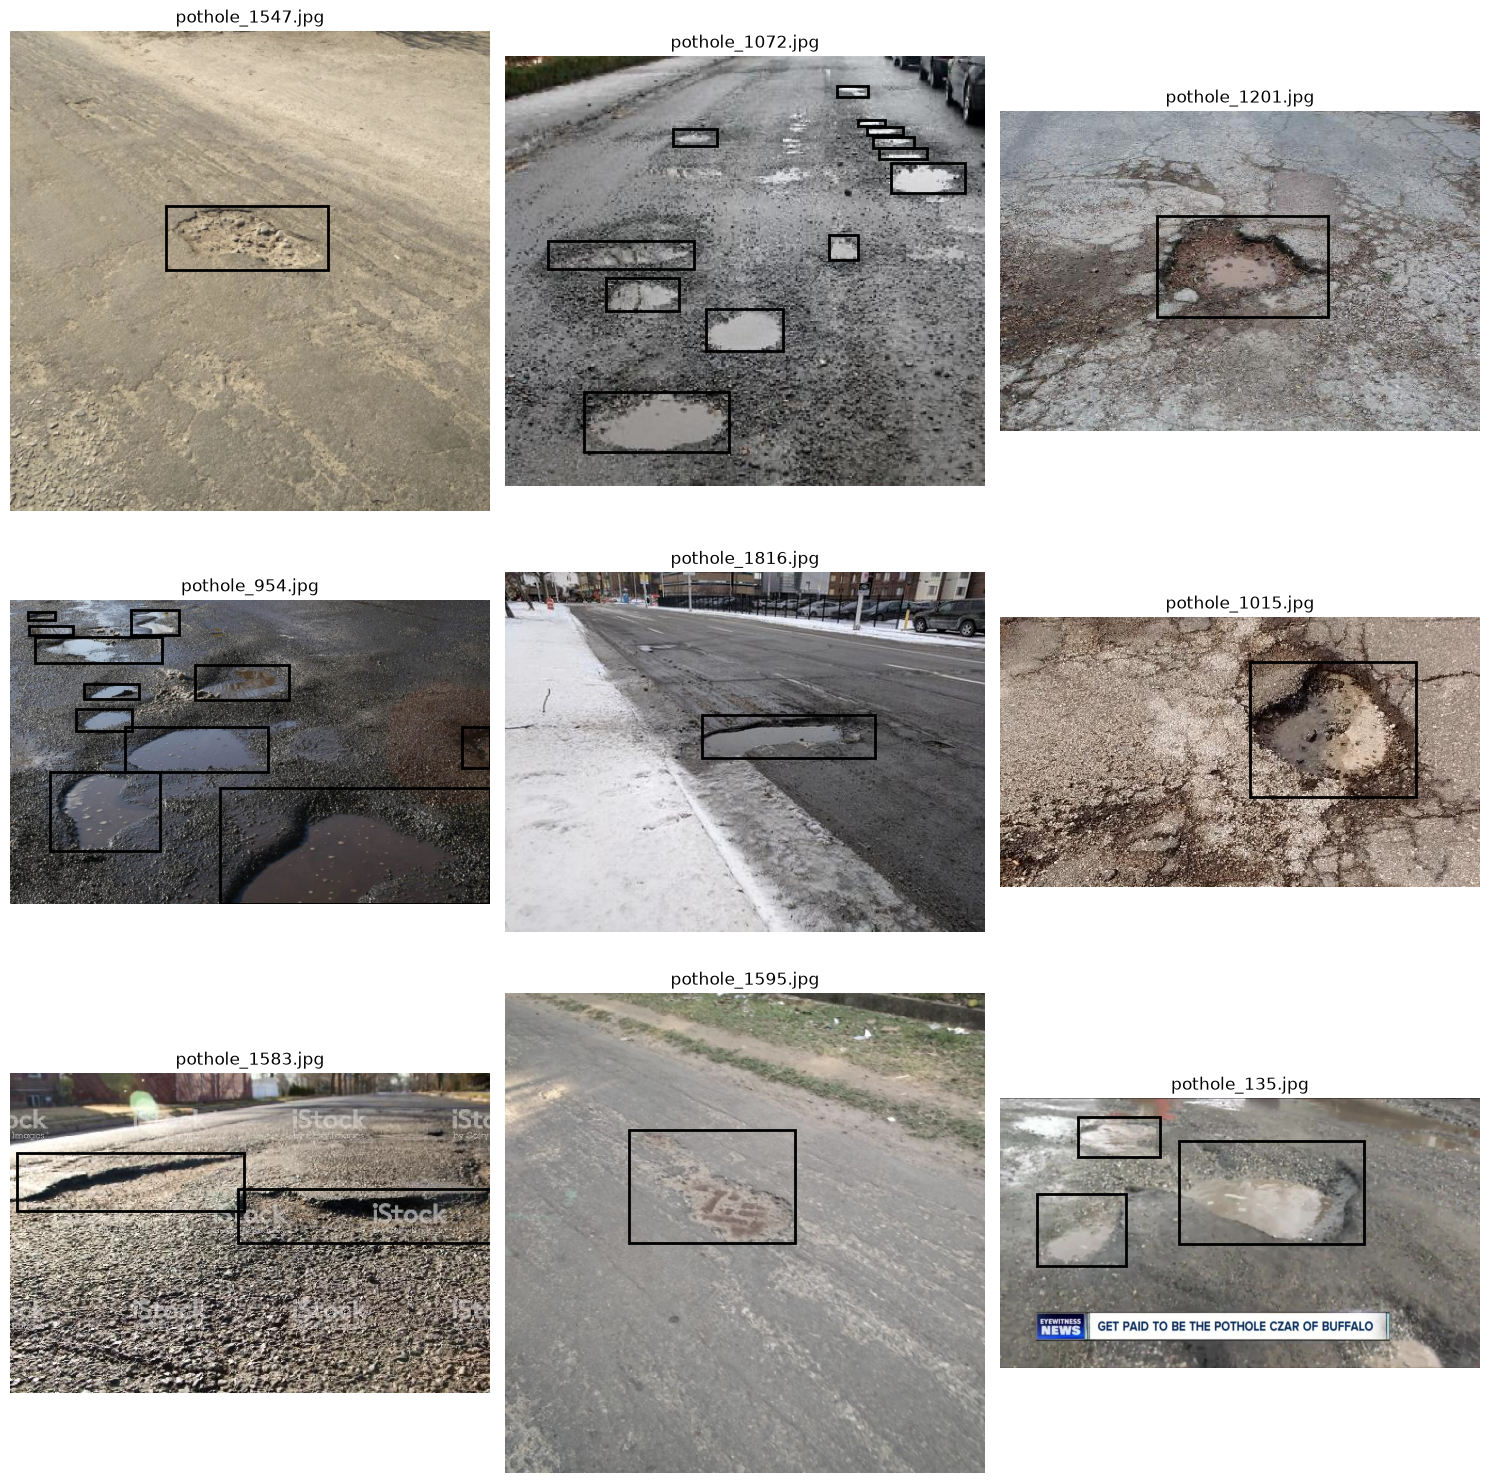

In [11]:
import random
import matplotlib.pyplot as plt
from PIL import Image

image_files = list(train_images.glob("*"))

random_images = random.sample(image_files, min(9, len(image_files)))

plt.figure(figsize=(15, 15))

for i, image_file in enumerate(random_images):
    image = Image.open(image_file)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(image_file.name)

    # Corresponding label
    label_file = train_labels / (image_file.stem + ".txt")

    if label_file.exists():
        with open(label_file, "r") as f:
            labels = f.readlines()

        width, height = image.size

        for line in labels:
            parts = line.strip().split()

            if len(parts) == 5:
                class_id, x, y, w, h = map(float, parts)

                x1 = (x - w / 2) * width
                y1 = (y - h / 2) * height
                box_width = w * width
                box_height = h * height

                rectangle = plt.Rectangle(
                    (x1, y1),
                    box_width,
                    box_height,
                    fill=False,
                    linewidth=2
                )

                plt.gca().add_patch(rectangle)

plt.tight_layout()
plt.show()

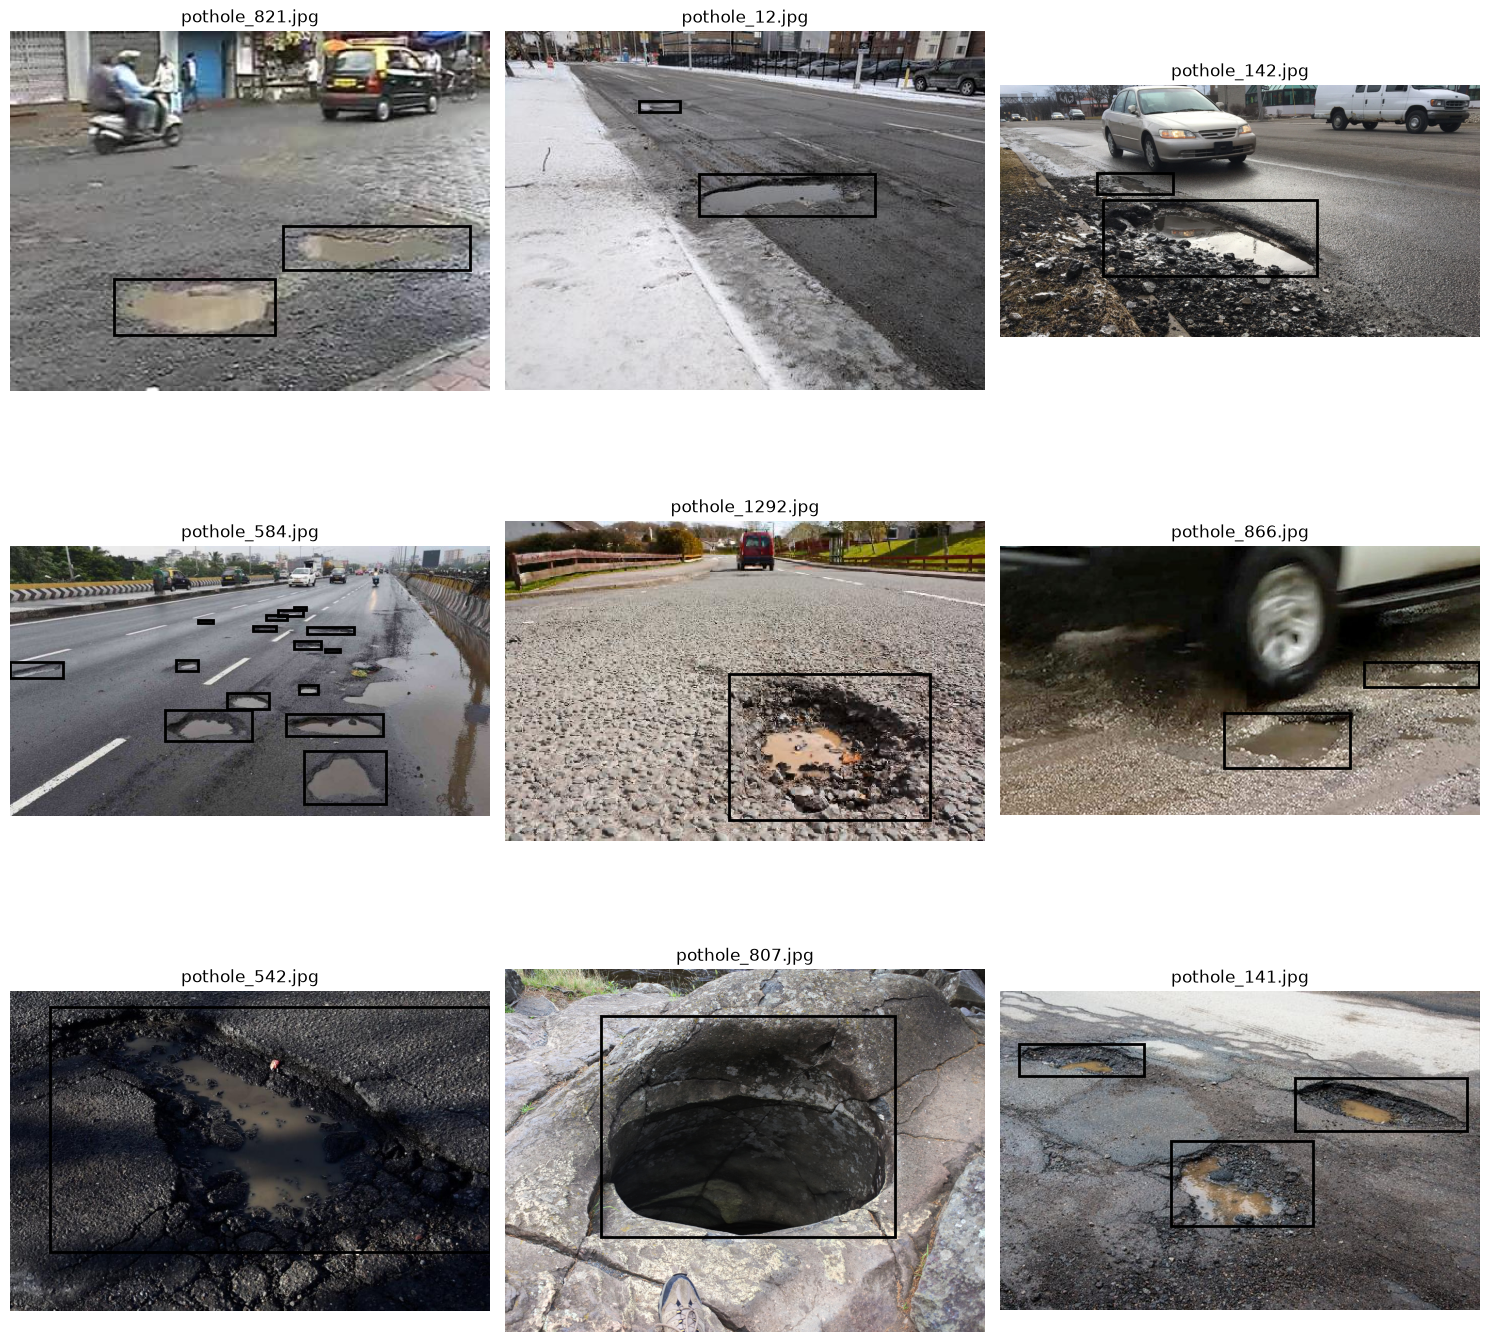

In [13]:
import random
import matplotlib.pyplot as plt
from PIL import Image

image_files = list(valid_images.glob("*"))

random_images = random.sample(image_files, min(9, len(image_files)))

plt.figure(figsize=(15, 15))

for i, image_file in enumerate(random_images):
    image = Image.open(image_file)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(image_file.name)

    label_file = valid_labels / (image_file.stem + ".txt")

    if label_file.exists():
        with open(label_file, "r") as f:
            labels = f.readlines()

        width, height = image.size

        for line in labels:
            parts = line.strip().split()

            if len(parts) == 5:
                class_id, x, y, w, h = map(float, parts)

                x1 = (x - w / 2) * width
                y1 = (y - h / 2) * height
                box_width = w * width
                box_height = h * height

                rectangle = plt.Rectangle(
                    (x1, y1),
                    box_width,
                    box_height,
                    fill=False,
                    linewidth=2
                )

                plt.gca().add_patch(rectangle)

plt.tight_layout()
plt.show()

In [14]:
print((dataset_path / "data.yaml").read_text())

train: /kaggle/input/potholes-detection-yolov8/train/images # e.g. /content/drive/MyDrive/Colab Notebooks/Pytorch Documentation/Datasets/Potholes/potholes-YOLOv8/train/images
val: /kaggle/input/potholes-detection-yolov8/valid/images # e.g. /content/drive/MyDrive/Colab Notebooks/Pytorch Documentation/Datasets/Potholes/potholes-YOLOv8/valid/images

nc: 1
names: ['pothole']
